##  Project Title: Real-Time Fraud Detection
A machine learning project to detect fraudulent transactions **before** they occur using features available prior to transaction completion.

## STEP 1: IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import os
import warnings
warnings.filterwarnings("ignore")

## STEP 2: LOAD DATASET

In [2]:
df = pd.read_csv("fraud.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [4]:
df.shape #checking numbers of rows and columns 

(11142, 10)

In [3]:
#checking null values 
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


## STEP 3: EDA

In [48]:
# Count Fraudlents
print(df["isFraud"].value_counts())
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    10000
1     1142
Name: count, dtype: int64
isFraud
0    89.750494
1    10.249506
Name: proportion, dtype: float64


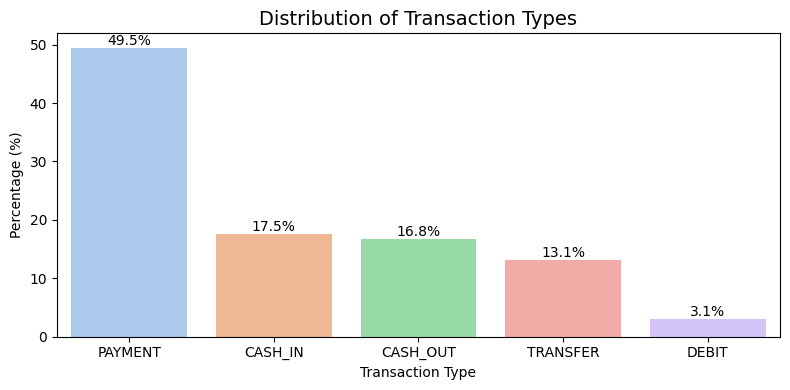

In [49]:
# distribution of transaction type 

# Calculate percentage
type_counts = df['type'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 4))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='pastel')
plt.title("Distribution of Transaction Types", fontsize=14)
plt.xlabel("Transaction Type")
plt.ylabel("Percentage (%)")

# Add percentage labels
for i, value in enumerate(type_counts.values):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

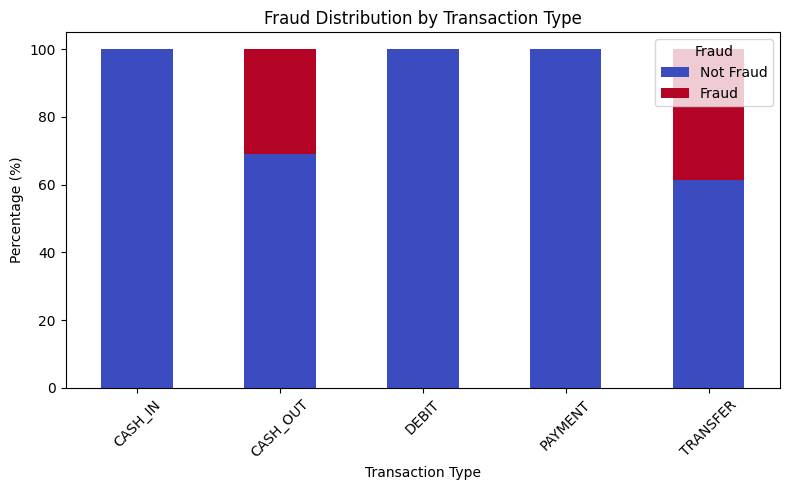

In [50]:
## categorical distribution vs traget 

fraud_per_type = df.groupby('type')['isFraud'].value_counts(normalize=True).unstack().fillna(0) * 100

fraud_per_type.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='coolwarm')
plt.title("Fraud Distribution by Transaction Type")
plt.ylabel("Percentage (%)")
plt.xlabel("Transaction Type")
plt.legend(title="Fraud", labels=["Not Fraud", "Fraud"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
## plotting continuous vs target 

cont_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig']  # continuous feature 
target = 'isFraud'

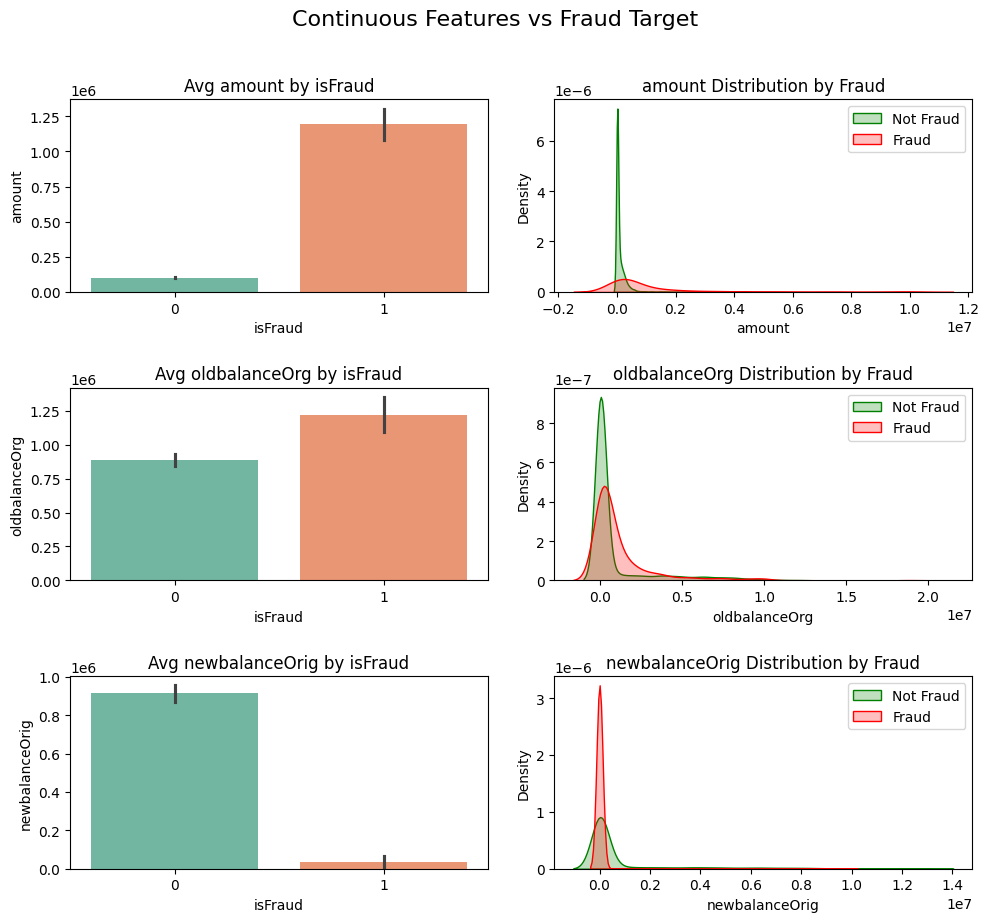

In [52]:
fig, axes = plt.subplots(len(cont_features), 2, figsize=(10, 3 * len(cont_features)))
fig.suptitle("Continuous Features vs Fraud Target", fontsize=16, y=1.02)

for i, feature in enumerate(cont_features):
    # Left: Barplot of mean by fraud
    sns.barplot(x=target, y=feature, data=df, ax=axes[i, 0], palette="Set2")
    axes[i, 0].set_title(f"Avg {feature} by isFraud")
    axes[i, 0].set_xlabel("isFraud")
    axes[i, 0].set_ylabel(f"{feature}")

    # Right: KDE/Histogram
    sns.kdeplot(data=df[df[target]==0], x=feature, fill=True, label='Not Fraud', ax=axes[i, 1], color='green')
    sns.kdeplot(data=df[df[target]==1], x=feature, fill=True, label='Fraud', ax=axes[i, 1], color='red')
    axes[i, 1].set_title(f"{feature} Distribution by Fraud")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

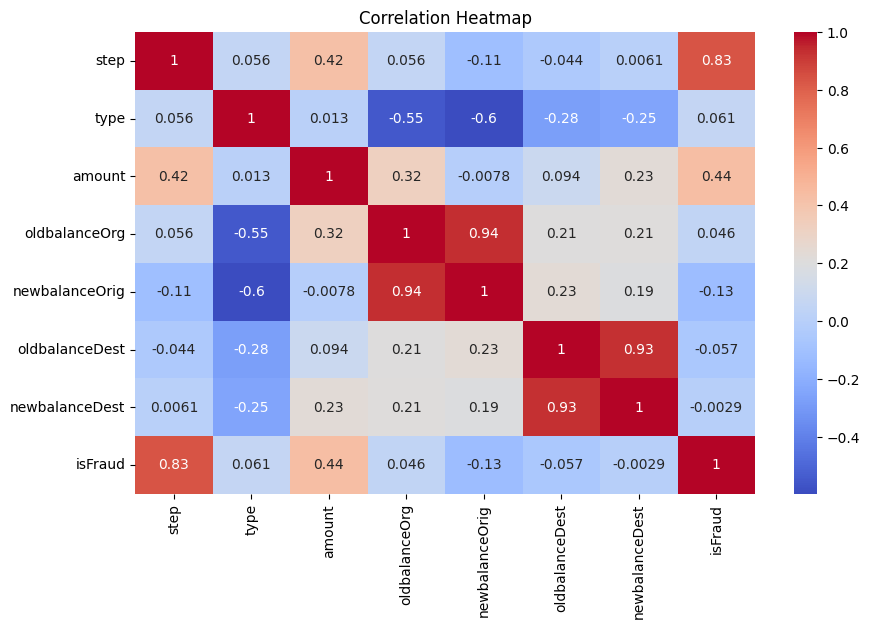

In [53]:
## heatmap

# Encode categorical features for EDA
df_encoded = df.copy()
df_encoded['type'] = df_encoded['type'].astype('category').cat.codes
corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


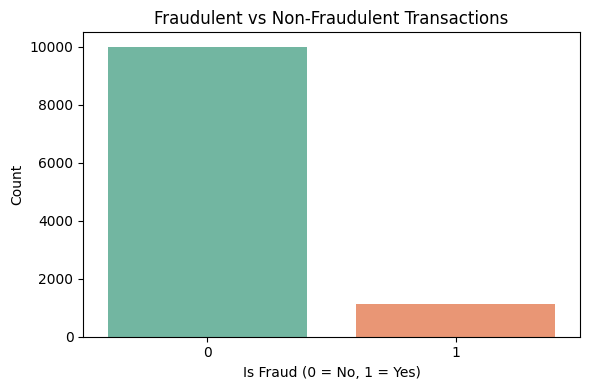

In [54]:
# Plot fraud vs non-fraud count
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='isFraud', palette='Set2')
plt.title("Fraudulent vs Non-Fraudulent Transactions")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()

plt.show()

## STEP 4: PREPROCESSING

FEATURE ENGINEERING

In [6]:
df['amount_ratio_old'] = df['amount'] / (df['oldbalanceOrg'] + 1e-5)

In [7]:
df['step_bin'] = pd.qcut(df['step'], q=10, labels=False,duplicates='drop')  # 10 bins
df = df.drop(columns=['step'])

In [8]:
df['receiver_is_merchant'] = df['nameDest'].str.startswith('M').astype(int) # derriving reciever id 


In [9]:
df['remainingBalance'] = df['oldbalanceOrg'] - df['amount'] # extracting remaining balance 

DROPPING FEATURE 


In [10]:
# Drop post-transaction fields
df = df.drop(['newbalanceOrig', 'newbalanceDest','oldbalanceDest','nameOrig', 'nameDest'], axis=1)

ENCODING TYPE

In [11]:
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])



In [12]:
df = df.drop(['type'], axis=1)

In [13]:
print(df.head())

    amount  oldbalanceOrg  isFraud  amount_ratio_old  step_bin  \
0    181.0          181.0        1               1.0         0   
1    181.0          181.0        1               1.0         0   
2   2806.0         2806.0        1               1.0         0   
3   2806.0         2806.0        1               1.0         0   
4  20128.0        20128.0        1               1.0         0   

   receiver_is_merchant  remainingBalance  type_encoded  
0                     0               0.0             4  
1                     0               0.0             1  
2                     0               0.0             4  
3                     0               0.0             1  
4                     0               0.0             4  


In [14]:
negatives_count = (df['remainingBalance'] < 0).sum()
print(f"Number of negative values in remainingBalance: {negatives_count}")

Number of negative values in remainingBalance: 4191


Removing outliers using clipping from remaining balance 

In [15]:
lower = df['remainingBalance'].quantile(0.01) #removing negatives
upper = df['remainingBalance'].quantile(0.99)
df['remainingBalance_clipped'] = df['remainingBalance'].clip(lower, upper)

## STEP 5: TRAIN TEST AND SPLIT

defining features 

In [65]:
num_cols = ['step_bin','amount', 'oldbalanceOrg', 'type_encoded','remainingBalance_clipped', 'amount_ratio_old']
bin_cols = ['receiver_is_merchant'] 

In [66]:
features = num_cols + bin_cols

X = df[features]
y = df['isFraud']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## STEP 6: SCALING AND SMOTE TO HANDLE DATA IMBALANCE 

In [68]:
scaler = StandardScaler() # scaling numerical features
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [69]:
# Adding small random noise to the numerical columns to avoid data leakage

np.random.seed(42)
for col in num_cols:
    X_train_scaled[col] += np.random.normal(0, 0.05, size=X_train_scaled.shape[0])
    X_test_scaled[col] += np.random.normal(0, 0.05, size=X_test_scaled.shape[0])

In [70]:
X_train_scaled['step_bin'] += np.random.normal(0, 1, size=X_train_scaled.shape[0])
X_test_scaled['step_bin'] += np.random.normal(0, 1, size=X_test_scaled.shape[0])

In [71]:
#smote to handle imbalance
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Keeping column names after SMOTE
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train_scaled.columns)
print("Class distribution after SMOTE:")
print(pd.Series(y_train_bal).value_counts())

Class distribution after SMOTE:
isFraud
0    7999
1    7999
Name: count, dtype: int64


## STEP 7: MODEL TRAINING AND EVALUATION 

In [72]:
#Training 
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        C=0.5,  # regularization strength
        class_weight='balanced'  # helps imbalanced data
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=7,             # limit tree depth
        min_samples_leaf=30,     # prevent memorization
        max_features='sqrt',
        random_state=42,
        class_weight='balanced'
    ),
    
    "XGBoost": XGBClassifier(n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'   ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15,          # smoother decision boundary
        weights='distance',      # distance-weighted voting
        metric='minkowski'
    )
}
results = {}
#Evaluation
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Train model
    model.fit(X_train_bal, y_train_bal)
    
    # Predict on test set
    y_pred = model.predict(X_test_scaled)
    
    # Classification report
    print(classification_report(y_test, y_pred))
    
    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:  # for KNN or other classifiers without predict_proba
        y_proba = model.predict(X_test_scaled)
    
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    #print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR-AUC : {pr_auc:.4f}")
    
    results[name] = model



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      2001
           1       0.51      0.96      0.66       228

    accuracy                           0.90      2229
   macro avg       0.75      0.93      0.80      2229
weighted avg       0.94      0.90      0.91      2229

PR-AUC : 0.8004

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2001
           1       0.70      0.93      0.80       228

    accuracy                           0.95      2229
   macro avg       0.85      0.94      0.89      2229
weighted avg       0.96      0.95      0.96      2229

PR-AUC : 0.9357

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2001
           1       0.70      0.95      0.80       228

    accuracy                           0.95      2229
   macro avg       0.85    

Cross validation

In [75]:
# Cross-Validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in results.items():
    try:
        auc_scores = cross_val_score(model, X_train_bal, y_train_bal,
                                     scoring='roc_auc', cv=cv)
        print(f"\n{name} AUC Scores: {auc_scores}")
        print(f"Mean AUC: {auc_scores.mean():.4f} | Std Dev: {auc_scores.std():.4f}")
    except Exception as e:
        print(f"\n{name} failed in CV: {e}")



Logistic Regression AUC Scores: [0.97887383 0.97351172 0.97711719 0.96873046 0.97361828]
Mean AUC: 0.9744 | Std Dev: 0.0035

Random Forest AUC Scores: [0.9939293  0.99280781 0.99332734 0.99304604 0.99510983]
Mean AUC: 0.9936 | Std Dev: 0.0008

XGBoost AUC Scores: [0.99502266 0.99353867 0.99379062 0.99335796 0.99528279]
Mean AUC: 0.9942 | Std Dev: 0.0008

KNN AUC Scores: [0.99298906 0.98961758 0.99173984 0.98956985 0.99454346]
Mean AUC: 0.9917 | Std Dev: 0.0019


SAVING MODEL

In [76]:
os.makedirs("models", exist_ok=True)
# results[name] = model  ✅
for name, model in results.items():
    filename = f"models/{name.replace(' ', '_')}.pkl"
    joblib.dump(model, filename)
    print(f"✅ Saved {name} model to {filename}")
    

✅ Saved Logistic Regression model to models/Logistic_Regression.pkl
✅ Saved Random Forest model to models/Random_Forest.pkl
✅ Saved XGBoost model to models/XGBoost.pkl
✅ Saved KNN model to models/KNN.pkl


SAVING SCALER AND FEATURES

In [77]:
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(X.columns.tolist(), 'models/feature_columns.pkl')
print("✅ Saved feature columns and scaler.")

✅ Saved feature columns and scaler.


## STEP 8: SELECTING BEST MODEL AND PR CURVE 


🏆 Best Model by PR-AUC: XGBoost
PR-AUC: 0.9387


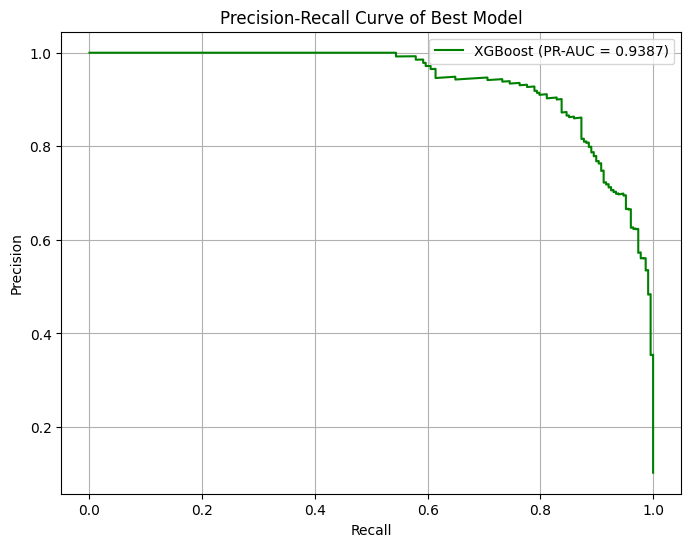

In [78]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Select best model based on PR-AUC
best_model_name = max(results, key=lambda name: average_precision_score(y_test, results[name].predict_proba(X_test_scaled)[:, 1]))
best_model = results[best_model_name]
print(f"\n🏆 Best Model by PR-AUC: {best_model_name}")

# Predict probabilities
y_probs_best = best_model.predict_proba(X_test_scaled)[:, 1]

# PR-AUC score
pr_auc_score_value = average_precision_score(y_test, y_probs_best)
print(f"PR-AUC: {pr_auc_score_value:.4f}")

# Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_probs_best)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'{best_model_name} (PR-AUC = {pr_auc_score_value:.4f})', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve of Best Model')
plt.legend()
plt.grid()
plt.show()


# FINANCIAL ANALYSIS 

In [79]:
# Predict on test set
y_pred = best_model.predict(X_test_scaled)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Financial assumptions
saved_per_tp = 500    # ₹500 saved for each fraud caught
loss_per_fn = 1000    # ₹1000 loss for each fraud missed
cost_per_fp = 10      # ₹10 cost for flagging legit transaction

# Compute
revenue_saved = tp * saved_per_tp
loss = fn * loss_per_fn + fp * cost_per_fp
net_profit = revenue_saved - loss

# Print the result
print("===  Financial Impact Analysis ===")
print(f"True Positives (Fraud caught): {tp}")
print(f"False Positives (Legit flagged): {fp}")
print(f"False Negatives (Fraud missed): {fn}")
print()
print(f"Revenue Saved (TP * ₹{saved_per_tp}): ₹{revenue_saved:,}")
print(f"Total Loss (FN * ₹{loss_per_fn} + FP * ₹{cost_per_fp}): ₹{loss:,}")
print()
print(f" Net Profit (Saved - Loss): ₹{net_profit:,}")

===  Financial Impact Analysis ===
True Positives (Fraud caught): 216
False Positives (Legit flagged): 94
False Negatives (Fraud missed): 12

Revenue Saved (TP * ₹500): ₹108,000
Total Loss (FN * ₹1000 + FP * ₹10): ₹12,940

 Net Profit (Saved - Loss): ₹95,060


FEATURE IMPORTANCE 

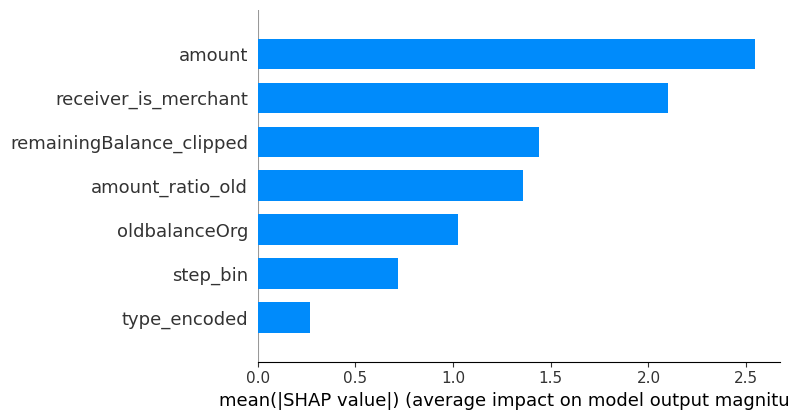

In [82]:
import shap

# Use TreeExplainer for tree-based models like XGBoost 
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X.columns, plot_type="bar")